# End To End ML for data scientist

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
pd.set_option("display.max_columns",None)

In [ ]:
df = pd.read_csv("german_credit_df.csv")

In [78]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [79]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [80]:
df.value_counts()

Unnamed: 0  Age  Sex     Job  Housing  Saving accounts  Checking account  Credit amount  Duration  Purpose              Risk
1           22   female  2    own      little           moderate          5951           48        radio/TV             bad     1
677         24   male    2    own      moderate         moderate          5595           72        radio/TV             bad     1
668         43   male    2    rent     little           little            4843           12        car                  bad     1
666         34   male    2    own      rich             moderate          3496           30        furniture/equipment  good    1
664         50   female  1    own      little           rich              1047           6         education            good    1
                                                                                                                               ..
321         32   male    2    own      little           little            1938           24    

In [81]:
df["Age"].value_counts()

Age
27    51
26    50
23    48
24    44
28    43
25    41
30    40
35    40
36    39
31    38
29    37
32    34
33    33
34    32
37    29
22    27
40    25
38    24
42    22
39    21
46    18
43    17
47    17
44    17
41    17
45    15
20    14
21    14
49    14
50    12
48    12
54    10
57     9
52     9
51     8
55     8
63     8
61     7
53     7
60     6
65     5
58     5
64     5
66     5
74     4
67     3
68     3
56     3
59     3
75     2
19     2
62     2
70     1
Name: count, dtype: int64

In [82]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [83]:
#(100-row,11column)
df.shape 

(1000, 11)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [85]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
df["Job"].unique()

array([2, 1, 3, 0], dtype=int64)

In [87]:
#display the missing value
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [88]:
df.duplicated().sum()

0

In [89]:
df = df.dropna().reset_index(drop= True)

In [90]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [91]:
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [92]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [93]:
df.drop(columns = "Unnamed: 0" , inplace = True)

In [94]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

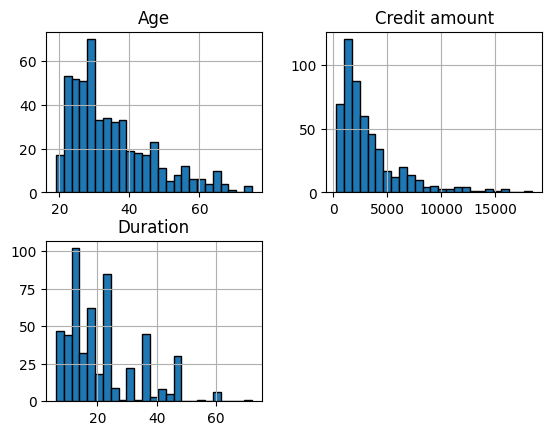

In [95]:
df[["Age","Credit amount","Duration"]].hist(bins=25,edgecolor="black")
plt.show()

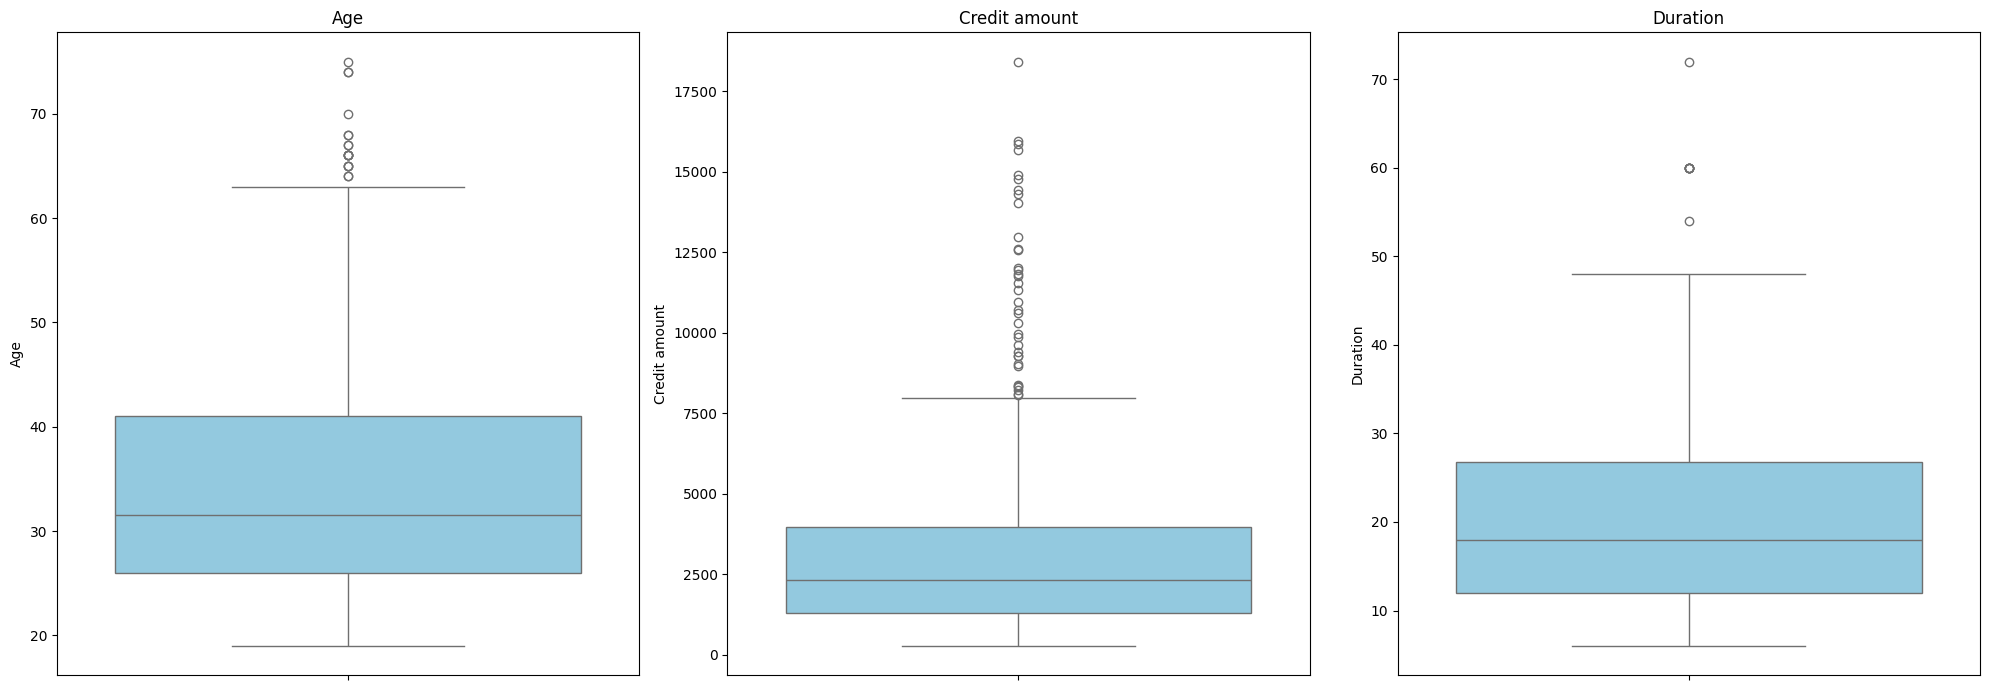

In [96]:
plt.figure(figsize = (20,7))
for i , col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color = "skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

In [97]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [98]:
l_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\3005226797.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\3005226797.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\3005226797.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().in

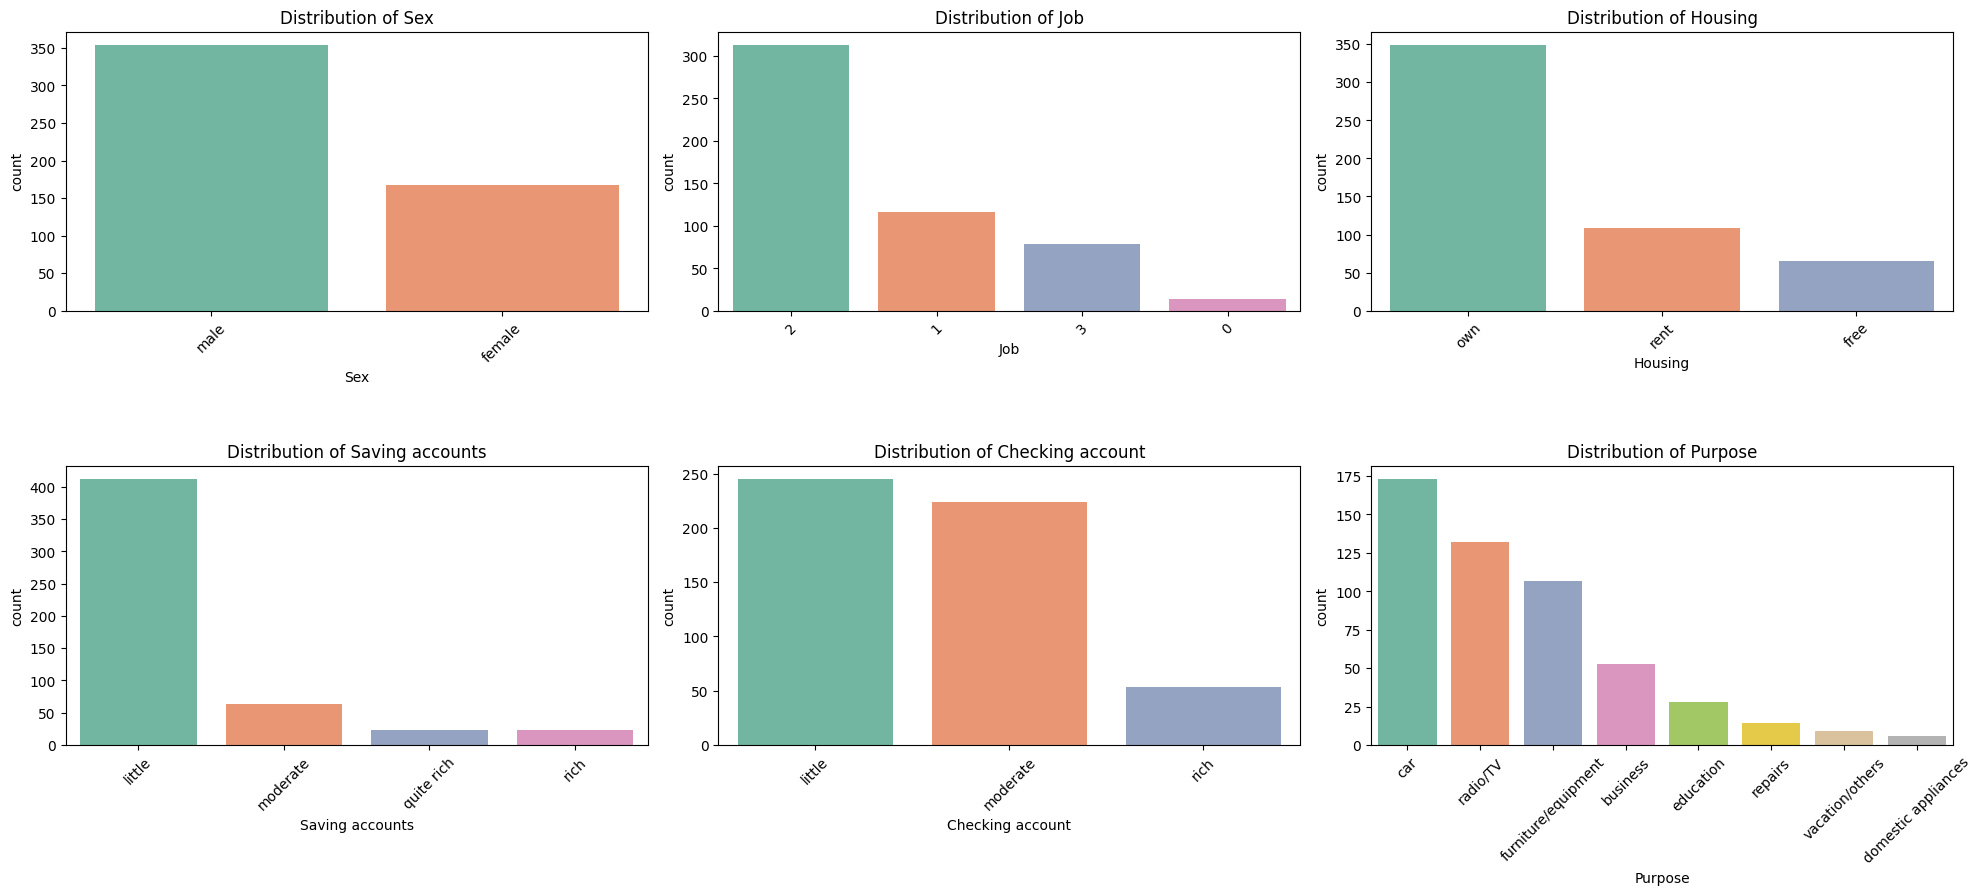

In [ ]:
plt.figure(figsize=(20, 12))

for i, col in enumerate(l_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(df=df, x=col, palette="Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [100]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()

In [101]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


In [102]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [103]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [104]:
pd.pivot_table(df, values = "Credit amount" , index = "Housing" , columns = "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


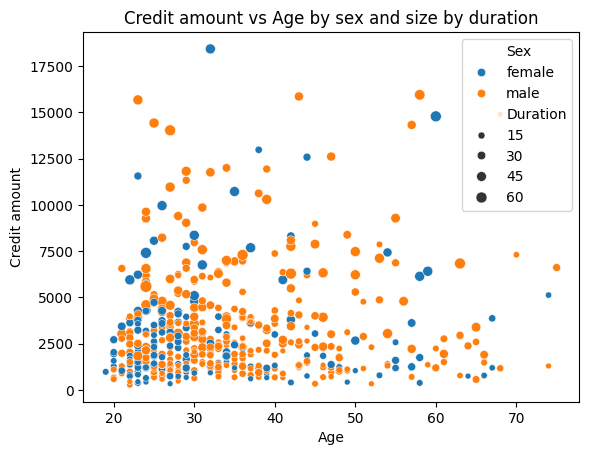

In [ ]:
sns.scatterplot(df=df , x= "Age", y= "Credit amount", hue = "Sex" , size = "Duration")
plt.title("Credit amount vs Age by sex and size by duration")
plt.show()

C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\292699741.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts",y="Credit amount",palette = "pastel")


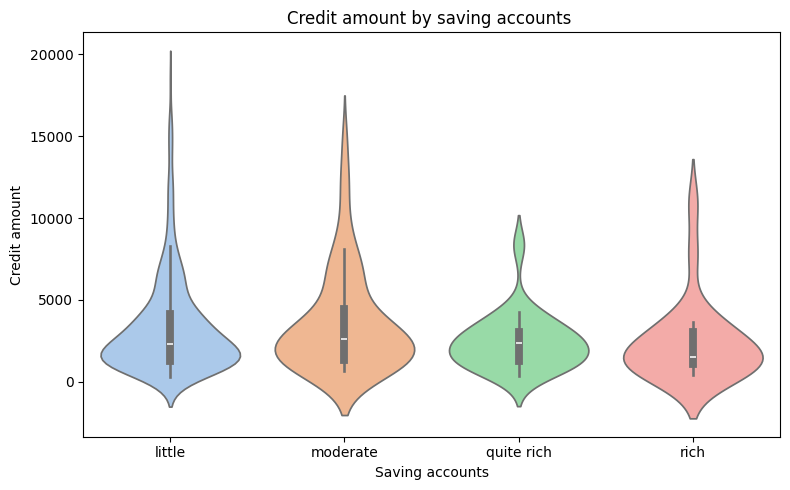

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(df=df, x="Saving accounts",y="Credit amount",palette = "pastel")
plt.title("Credit amount by saving accounts ")
plt.tight_layout()
plt.show()

In [107]:
df["Risk"].value_counts(normalize=True)

Risk
good    0.557471
bad     0.442529
Name: proportion, dtype: float64

C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\1712291351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="pastel")
C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\1712291351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="pastel")
C:\Users\nhaxy\AppData\Local\Temp\ipykernel_311448\1712291351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Risk", y=col, palette="pastel")


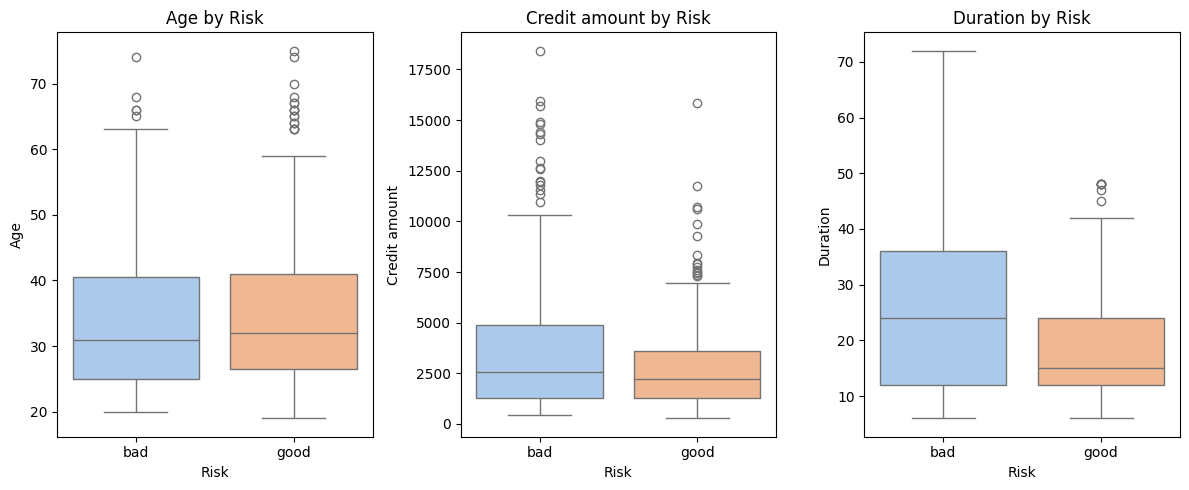

In [ ]:
plt.figure(figsize=(12, 5))

for i, col in enumerate(["Age", "Credit amount", "Duration"]):  # fix column name
    plt.subplot(1, 3, i + 1)
    sns.boxplot(df=df, x="Risk", y=col, palette="pastel")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [109]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [110]:
l_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

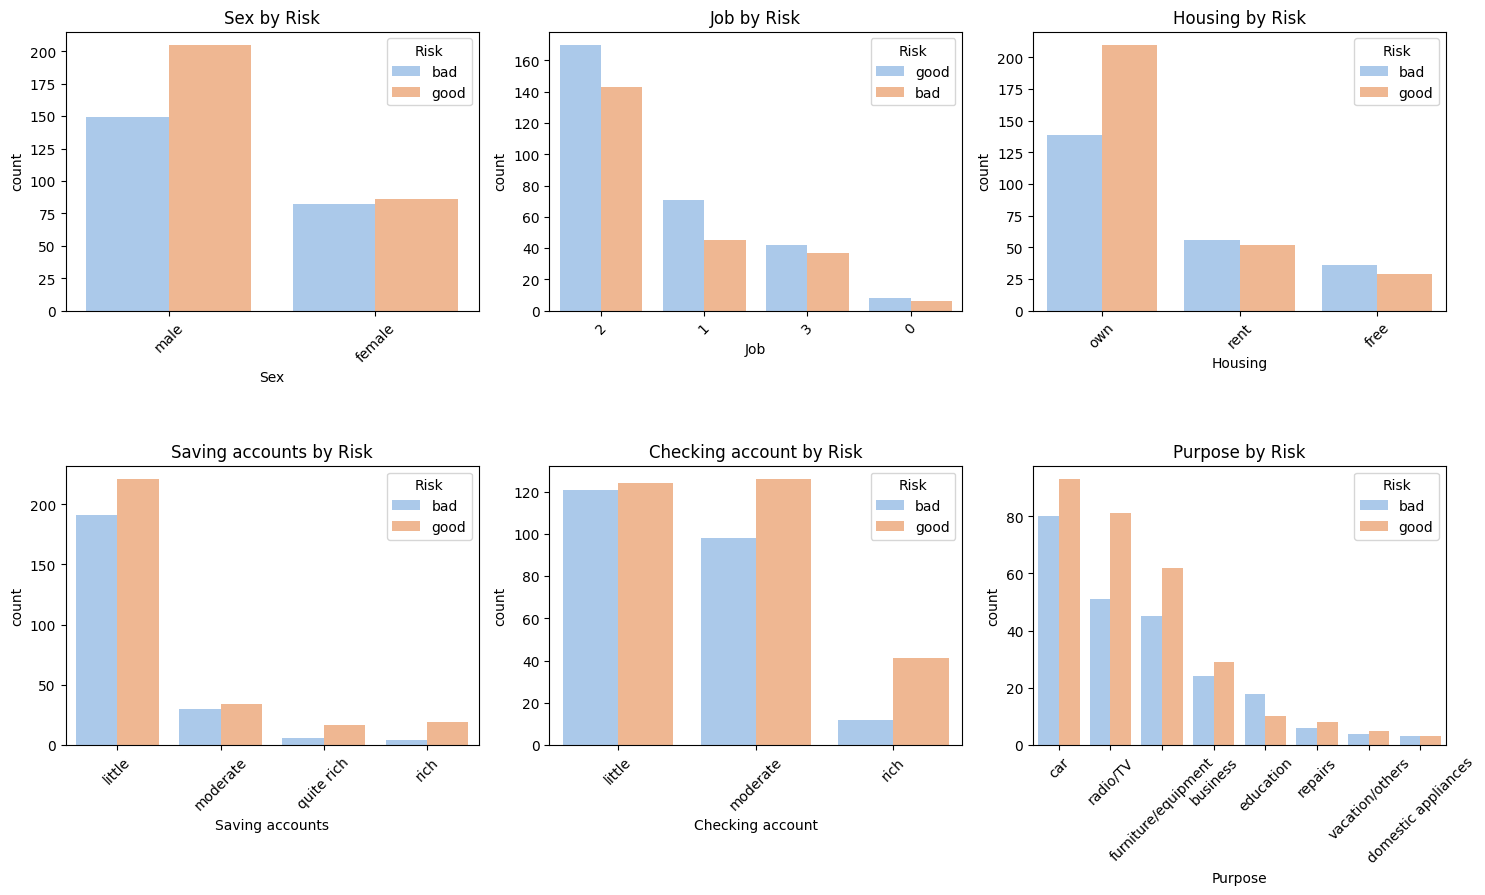

In [ ]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(l_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(
        df=df,
        x=col,
        hue="Risk",
        palette="pastel",
        order=df[col].value_counts().index   
    )
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [112]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [113]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration']

In [114]:
target = "Risk"

In [115]:
df_model = df[features + [target]].copy()
df_model

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad
...,...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24,good
518,30,male,3,own,little,little,3959,36,good
519,40,male,3,own,little,little,3857,30,good
520,23,male,2,free,little,little,1845,45,bad


In [116]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [117]:
cats_col = df_model.select_dtypes(include="object").columns.drop("Risk")
cats_col

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [118]:
le_dict = {}

In [119]:
for col in cats_col:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le,f"{col}_encoder.pkl")

In [120]:
le_target = LabelEncoder()

In [121]:
target

'Risk'

In [122]:
df_model[target]  = le_target.fit_transform(df_model[target])

In [123]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [124]:
joblib.dump(le_target , "target_encoder.pkl")

['target_encoder.pkl']

In [125]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [126]:
from sklearn.model_selection import train_test_split

X = df_model.drop(target , axis =1)
y = df_model[target]

In [127]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [128]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int32

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [130]:
X_train.shape

(417, 8)

In [131]:
X_test.shape

(105, 8)

In [132]:
y = y.values.ravel()


In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [134]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}



In [135]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)          # train model
    y_pred = model.predict(X_test)       # predict on test set
    
    acc = accuracy_score(y_test, y_pred) # calculate accuracy
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", round(acc, 4))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))




Logistic Regression
Accuracy: 0.581
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.48      0.52        50
           1       0.59      0.67      0.63        55

    accuracy                           0.58       105
   macro avg       0.58      0.58      0.57       105
weighted avg       0.58      0.58      0.58       105


KNN
Accuracy: 0.5619
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.44      0.49        50
           1       0.57      0.67      0.62        55

    accuracy                           0.56       105
   macro avg       0.56      0.56      0.55       105
weighted avg       0.56      0.56      0.56       105


Decision Tree
Accuracy: 0.6095
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        50
           1       0.62      0.65      0.64        55

    accuracy          

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.dfFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
}).sort_values(by="Accuracy", ascending=False)

print(results_df)



                 Model  Accuracy
4    Gradient Boosting  0.657143
2        Decision Tree  0.609524
3        Random Forest  0.609524
0  Logistic Regression  0.580952
1                  KNN  0.561905


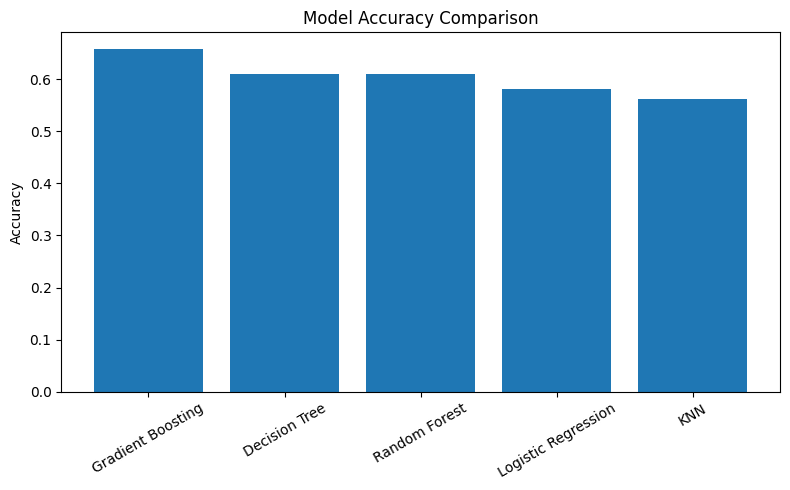

In [137]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()


In [138]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

print("Best Model:", best_model_name)



Best Model: Gradient Boosting


In [139]:
cm = confusion_matrix(y_test, best_preds)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[30 20]
 [16 39]]


In [140]:
from sklearn.model_selection import GridSearchCV

gb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')

In [141]:
print("Best Params:", gb_grid.best_params_)
print("Best CV Accuracy:", gb_grid.best_score_)


Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Accuracy: 0.6834767641996558


In [142]:
best_gb = gb_grid.best_estimator_

gb_preds = best_gb.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Tuned Gradient Boost Accuracy:", accuracy_score(y_test, gb_preds))
print(classification_report(y_test, gb_preds))


Tuned Gradient Boost Accuracy: 0.638095238095238
              precision    recall  f1-score   support

           0       0.64      0.56      0.60        50
           1       0.64      0.71      0.67        55

    accuracy                           0.64       105
   macro avg       0.64      0.63      0.63       105
weighted avg       0.64      0.64      0.64       105



Tuned Gradient Boosting Model Performance

After training and comparing several machine learning models, Gradient Boosting showed the best performance, so we selected it for further improvement. We then applied hyperparameter tuning using GridSearchCV to find better settings for the model.

After fine-tuning, the model achieved an accuracy of about 64% on the test dataset. This means that out of all test samples, the model correctly predicted around 64 out of every 100 cases. This result shows a small change compared to the original model, which had around 66% accuracy. This tells us that fine-tuning alone cannot always guarantee improvement, especially when the dataset is small or the features are not very strong.

When we look at each class, the model predicts Class 1 better than Class 0. For Class 1, the recall is 71%, which means the model can correctly find most of the positive cases. For Class 0, the recall is only 56%, meaning some negative cases are still misclassified as positive. This indicates that the model is slightly biased toward predicting Class 1.

The precision for both classes is around 64%, which means that when the model makes a prediction, about two-thirds of the time it is correct. The F1-score, which balances precision and recall, is 0.60 for Class 0 and 0.67 for Class 1, again showing better performance on Class 1.

Overall, the tuned Gradient Boosting model performs reasonably but is still limited by the quality and amount of data. To improve the model further, we would need better feature engineering, better encoding of categorical variables, or a larger dataset. More advanced models such as XGBoost or LightGBM could also be tested to achieve better performance.

After hyperparameter tuning, the Gradient Boosting model achieved 64% accuracy, performing better on Class 1 than Class 0, and further improvement would require better features or more data rather than only tuning the model.

In [143]:
final_model = best_gb   # or best_rf


In [144]:
import joblib

joblib.dump(final_model, "final_model.pkl")
print("Model saved as final_model.pkl")


Model saved as final_model.pkl


In [145]:
import joblib

model = joblib.load("final_model.pkl")
print("Model loaded successfully")


Model loaded successfully


In [147]:
X.columns


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration'],
      dtype='object')

In [ ]:
import pandas as pd

new_df = pd.dfFrame([{
    "Age": 45,
    "Sex": 1,                 # example: male=1, female=0 (must match your encoding)
    "Job": 2,
    "Housing": 1,             # example encoded
    "Saving accounts": 2,     # example encoded
    "Checking account": 1,    # example encoded
    "Credit amount": 1200,
    "Duration": 12
}])


In [ ]:
prediction = model.predict(new_df)
print("Prediction:", prediction)


Prediction: [1]


In [ ]:
proba = model.predict_proba(new_df)[0]
print("Class probabilities:", proba)


Class probabilities: [0.34152118 0.65847882]


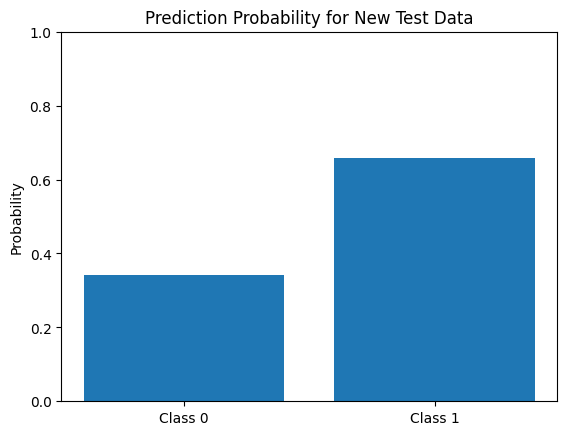

In [ ]:
import matplotlib.pyplot as plt

classes = ["Class 0", "Class 1"]

plt.figure()
plt.bar(classes, proba)
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.title("Prediction Probability for New Test df")
plt.show()


In [ ]:
pred = model.predict(new_df)[0]
print("Final Prediction Class:", pred)


Final Prediction Class: 1
